## Sequential chainning and Conditional Routing

## Boilerplate code

In [23]:
import langchain 
import os 
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
llm=ChatGroq(api_key=groq_api_key, model="openai/gpt-oss-120b", temperature=0.2)


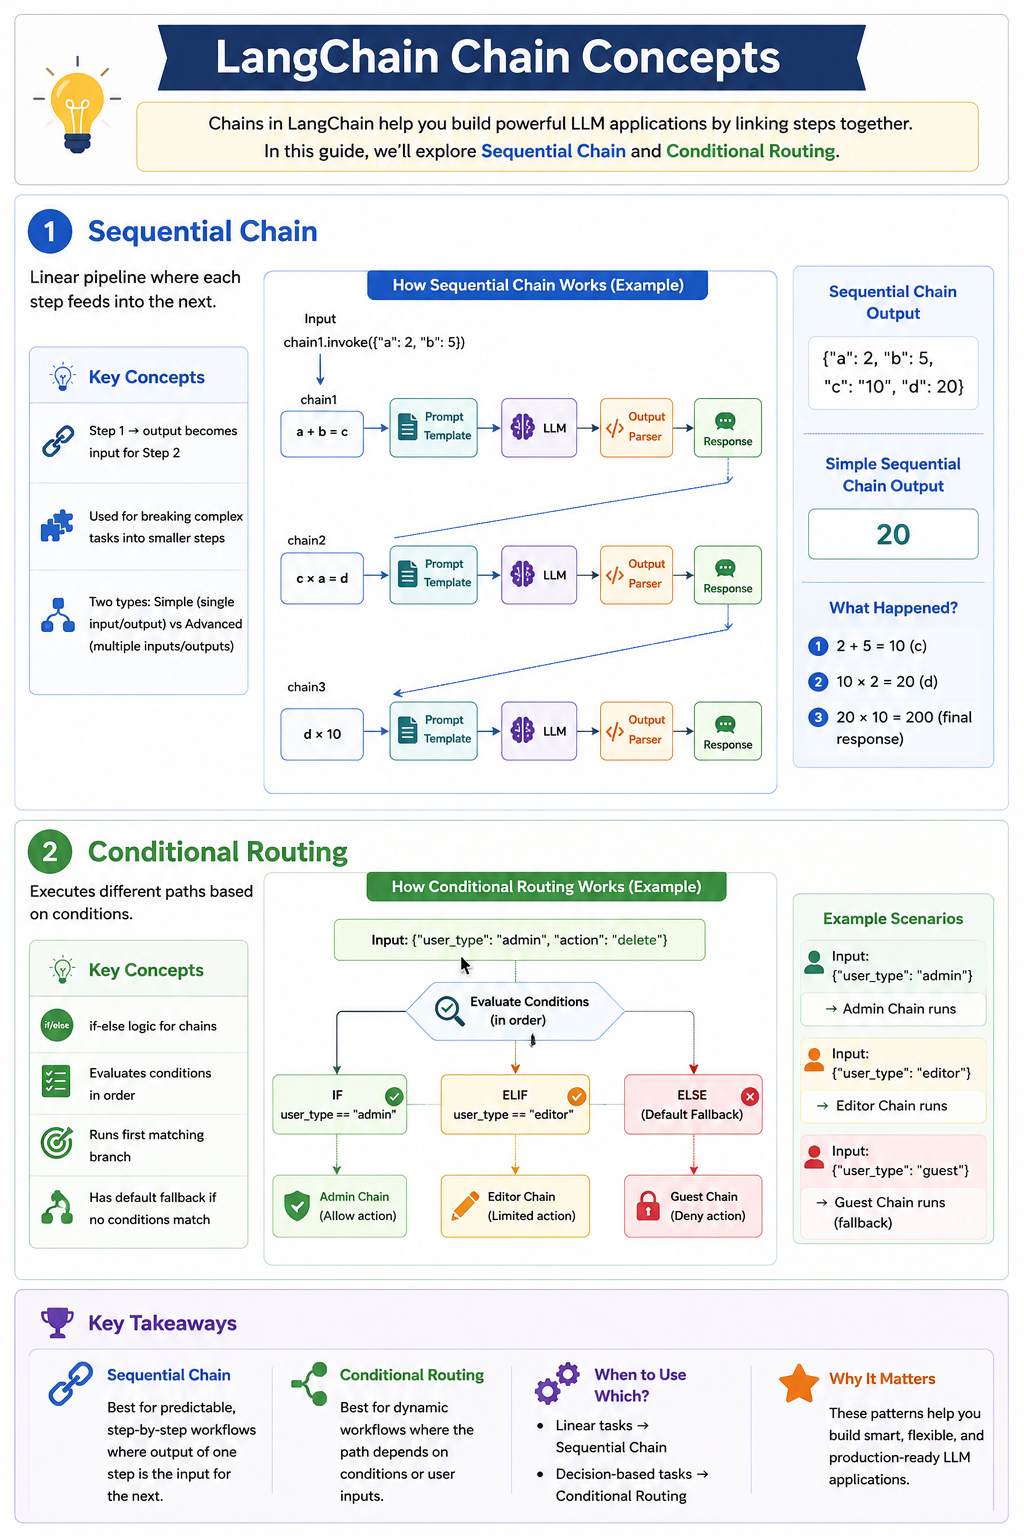

In [18]:
prompt1=ChatPromptTemplate.from_template("How much it is {a}+{b}. Answer only with the result /n Result: ")

first_chain = prompt1 | llm | StrOutputParser()

prompt2 = ChatPromptTemplate.from_template("How much it is {a}*{c}.")
second_chain = prompt2 | llm | StrOutputParser()

### Sequential chain - we get all intermediate outputs

In [19]:
from langchain_core.runnables import RunnablePassthrough

complete_chain=(RunnablePassthrough.assign(c=first_chain) | RunnablePassthrough.assign(d=second_chain))

result = complete_chain.invoke({'a':5,'b':10})
print(result)

{'a': 5, 'b': 10, 'c': 'Result: 15', 'd': 'The expression you gave can be read as:\n\n\\[\n5 \\times 15\n\\]\n\nMultiplying those numbers:\n\n\\[\n5 \\times 15 = 75\n\\]\n\nSo the result is **75**.'}


#### for only get the final result we use - **Simple Sequential Chain**

In [21]:
from operator import itemgetter

# Complete sequential chain using LCEL
complete_chain = (
    {
        "a": itemgetter("a"), # can use lambda but itemgetter is simpler
        "b": itemgetter("b"),
        "c": first_chain
    }
    | second_chain
    | PromptTemplate.from_template("Just print the result of this calculation and nothing else: {input}")
    | llm
    | StrOutputParser()
)

result = complete_chain.invoke({'a': 2, 'b': 3})
print(result)


10


## Examples
###  Company name, motto , description generator from product idea

In [25]:


company_name_prompt = ChatPromptTemplate.from_template(
    "You are a company name generator from the given product idea. Answer with max two words as output. Here is the product idea: {product_idea}"
)
company_name_chain = company_name_prompt | llm | StrOutputParser()

description_prompt = ChatPromptTemplate.from_template(
    "You are a company name description generator from the give company name and idea. Describe the company in two lines. Here is the product idea: {product_idea} and company name: {company_name}"
)
description_chain = description_prompt | llm | StrOutputParser()

motto_prompt = ChatPromptTemplate.from_template(
    "You are a company motto generator from the give company name, idea and description. Motto should be catchy and short. Just give me one. Here is the product idea: {product_idea} and company name: {company_name} and company description {company_description}"
)
motto_chain = motto_prompt | llm | StrOutputParser()


In [30]:
from pprint import pprint

complete_chain = (
    RunnablePassthrough.assign(company_name=company_name_chain)
    | RunnablePassthrough.assign(company_description=description_chain)
    | RunnablePassthrough.assign(motto=motto_chain)
)

res = complete_chain.invoke({"product_idea": "A platform that provide AI generated content for social media posts."})
print(res)


{'product_idea': 'A platform that provide AI generated content for social media posts.', 'company_name': 'PostPulse', 'company_description': 'PostPulse is an AI‑powered platform that crafts engaging, ready‑to‑post social media content tailored to each brand’s voice.  \nIt streamlines content creation, boosting consistency and reach while saving marketers hours of manual effort.', 'motto': 'Pulse Your Posts with AI.'}


In [32]:
# All chains use same variable name "text"
chain1 = PromptTemplate.from_template("Just answer 'One' for this: {text}") | llm | StrOutputParser()
chain2 = PromptTemplate.from_template("Just answer 'Two' for this: {text}") | llm | StrOutputParser()
chain3 = PromptTemplate.from_template("Just answer 'Three' for this: {text}") | llm | StrOutputParser()
chain4 = PromptTemplate.from_template("Just print what you see: {text}") | llm | StrOutputParser()

# Simple sequential pipe
chain = chain1 | chain2 | chain3 | chain4

# Execute
result = chain.invoke({"text": "AI is powerful technology"})
print(result)


Three


## Additional method to define Chain 


In [34]:
from langchain_core.runnables import RunnableSequence

chain1 = PromptTemplate.from_template("Just answer 'One' for this: {text}") | llm | StrOutputParser()
chain2 = PromptTemplate.from_template("Just answer 'Two' for this: {text}") | llm | StrOutputParser()
chain3 = PromptTemplate.from_template("Just answer 'Three' for this: {text}") | llm | StrOutputParser()
chain4 = PromptTemplate.from_template("Just print what you see: {text}") | llm | StrOutputParser()

chain = RunnableSequence(first=chain1, middle=[chain2, chain3], last=chain4)

# **Execute**
result = chain.invoke({"text": "AI is powerful technology"})
print(result)


Three


Chain using .pipe

In [40]:
from langchain_core.prompts import PromptTemplate
# # prompt_template | llm | StrOutputParser()
prompt_template = PromptTemplate.from_template(
    "Answer the following question briefly:\n{question}"
)
chain = prompt_template.pipe(llm).pipe(StrOutputParser())

chain.invoke("what is Langchain?")


'LangChain is an open‑source framework for building applications that combine large language models (LLMs) with external data sources and tools. It provides modular components—like prompts, memory, agents, and data connectors—so developers can chain together LLM calls, retrieve information from APIs or databases, and manage conversational state, enabling more powerful and context‑aware AI applications.'

## Conditional Routing

In [42]:
from langchain_core.runnables import RunnableBranch, RunnableLambda, RunnablePassthrough

def data_for_super_admin(payload):
    return {
        "id": 1001,
        "name": "Rajesh Kumar",
        "email": "rajesh.kumar@company.com",
        "phone": "+91-9876543210",
        "role": "super_admin",
        "department": "IT Operations",
        "employee_id": "SA001",
        "permissions": ["all_access", "user_management", "system_config", "billing_access", "audit_logs", "role_management", "organization_manageme"],
        "access_level": 10,
        "salary": 2500000,
        "team_members": ["1002", "1003", "1004", "1005"],
        "projects": ["Infrastructure", "Security", "Compliance"],
        "certifications": ["AWS Certified", "CISSP", "PMP"],
        "created_at": "2023-01-15T09:30:00Z",
        "last_login": "2025-09-20T10:15:22Z",
        "login_count": 1247,
        "failed_attempts": 0,
        "session_timeout": 480,
        "status": "active"
    }


def data_for_admin(payload):
    return {
        "id": 1002,
        "name": "Priya Sharma",
        "email": "priya.sharma@company.com",
        "role": "admin",
        "department": "Marketing",
        "permissions": ["user_management", "content_edit", "reports_view", "team_management"],
        "access_level": 7,
        "reporting_manager": "1001",
        "team_members": ["1003"],
        "created_at": "2023-03-22T14:45:00Z",
        "last_login": "2025-09-20T08:30:45Z",
        "status": "active"
    }

def data_for_user(payload):
    return {
        "id": 1003,
        "name": "Arjun Patel",
        "email": "arjun.patel@gmail.com",
        "role": "user",
        "permissions": ["profile_edit", "content_view"],
        "created_at": "2024-06-10T11:20:00Z",
        "last_login": "2025-09-19T16:42:18Z",
        "status": "active"
    }

prompt_template = PromptTemplate.from_template("Simplify this data in clean table format for human consumption. Here is the data: {data}")

super_admin_chain = RunnablePassthrough.assign(data=RunnableLambda(data_for_super_admin)) | prompt_template | llm | StrOutputParser()
admin_chain = RunnablePassthrough.assign(data=RunnableLambda(data_for_admin)) | prompt_template | llm | StrOutputParser()
user_chain = RunnablePassthrough.assign(data=RunnableLambda(data_for_user)) | prompt_template | llm | StrOutputParser()

role_router = RunnableBranch(
    (lambda x: x['role'] == 'super_admin', super_admin_chain),
    (lambda x: x['role'] == 'admin', admin_chain),
    user_chain,
)

role_router.invoke({"role": "super_admin"})


'**Rajesh Kumar – Super Admin Profile**\n\n| Field | Details |\n|-------|---------|\n| **ID** | 1001 |\n| **Name** | Rajesh Kumar |\n| **Email** | rajesh.kumar@company.com |\n| **Phone** | +91‑9876543210 |\n| **Role** | Super Admin |\n| **Department** | IT Operations |\n| **Employee ID** | SA001 |\n| **Access Level** | 10 |\n| **Salary (₹)** | 2,500,000 |\n| **Status** | Active |\n| **Created At** | 2023‑01‑15 09:30\u202fUTC |\n| **Last Login** | 2025‑09‑20 10:15\u202fUTC |\n| **Login Count** | 1,247 |\n| **Failed Login Attempts** | 0 |\n| **Session Timeout (min)** | 480 |\n| **Permissions** | all_access, user_management, system_config, billing_access, audit_logs, role_management, organization_manageme |\n| **Team Members (IDs)** | 1002, 1003, 1004, 1005 |\n| **Projects** | Infrastructure, Security, Compliance |\n| **Certifications** | AWS Certified, CISSP, PMP |\n\n*All list‑type fields are shown as comma‑separated values for quick reference.*'

##### Creadits for **Computer Lab** for best flow of teaching Langchain